# 🟨⚽ Análise de Arbitragem e Odds — Libertadores 2026

**Objetivos deste notebook:**

1. Analisar a influência da **arbitragem** (faltas, cartões) nos resultados da fase de grupos e oitavas;
2. Testar estatisticamente essas relações (**ANOVA** e **correlação de Pearson**);
3. Comparar as previsões do **modelo de Poisson** com as **probabilidades implícitas das odds** (Bzzoiro Sports Data);
4. Avaliar se a **integração de odds** melhora a acurácia do modelo (acurácia e Brier Score);
5. Identificar quais estatísticas mais se relacionam com a classificação.

**Fontes de dados:**

* `data/processed/libertadores_estatisticas_detalhadas.csv` — API Futebol (com fallback para `data/examples/`);
* `data/processed/libertadores_odds.csv` — Bzzoiro Sports Data (com fallback para `data/examples/`).

> ⚠️ Sem as chaves de API, o notebook usa as **bases de exemplo** de `data/examples/`, geradas de forma determinística por `src/generate_example_data.py`. Os efeitos da arbitragem nessas bases são **amplificados** (em relação a dados reais) para fins de ilustração metodológica.


## 1. Configuração e carregamento dos dados

In [1]:
import sys
from pathlib import Path

# Garante que o notebook encontre os módulos de src/, independentemente do
# diretório de trabalho do kernel
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT / ".." / "src").exists():
    ROOT = ROOT / ".."
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

from src.preprocessing import Preprocessor
from src.poisson import PoissonScoreModel

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titleweight"] = "bold"

VERDE = "#12a05c"
CINZA = "#8a8f98"
VERMELHO = "#d9534f"
AMARELO = "#e2b13c"

print(f"Pandas {pd.__version__} · Python {sys.version.split()[0]}")

Pandas 2.3.3 · Python 3.10.11


In [2]:
pre = Preprocessor()

# Estatísticas detalhadas (partidas) e odds processadas
partidas = pre.load_estatisticas()
odds = pre.load_odds()

# Tabela da fase de grupos + modelo de Poisson (mesma parametrização do dashboard)
grupos_df, _, _ = pre.load_data()
grupos = pre.create_features(grupos_df)
model = PoissonScoreModel(home_advantage=1.15, max_goals=10)
model.fit(grupos)

# Colunas derivadas (totais por partida)
partidas = pre.process_estatisticas(partidas)
partidas["data"] = pd.to_datetime(partidas["data"], errors="coerce")

display(Markdown(
    f"**{len(partidas)} partidas** com estatísticas detalhadas e "
    f"**{len(odds)} partidas** com odds 1X2. "
    f"Árbitros distintos: **{partidas['arbitro'].nunique()}**."
))

**48 partidas** com estatísticas detalhadas e **48 partidas** com odds 1X2. Árbitros distintos: **8**.

## 2. Visão geral dos dados

Colunas disponíveis: identificação da partida, placar, árbitro e — para cada time — faltas, cartões, posse, passes (certos/errados), finalizações (totais/no gol/fora), escanteios, impedimentos e defesas do goleiro.

In [3]:
print("Partidas:", partidas.shape, "| Odds:", odds.shape)
display(partidas.head(3).T)
print()
print("Valores ausentes por coluna (principais):")
display(partidas[["arbitro", "faltas_mandante", "cartoes_amarelos_mandante",
                  "posse_mandante", "passes_certos_mandante",
                  "finalizacoes_mandante", "defesas_mandante"]].isna().sum())

Partidas: (48, 50) | Odds: (48, 18)


,0,1,2
partida_id,1001,1002,1003
data,2026-04-15 00:00:00,2026-04-14 00:00:00,2026-04-15 00:00:00
fase,Fase de Grupos,Fase de Grupos,Fase de Grupos
rodada,1ª Rodada,1ª Rodada,1ª Rodada
grupo,Grupo A,Grupo A,Grupo A
mandante,Deportes Tolima,Flamengo,Estudiantes
visitante,Palmeiras,Independiente Rivadavia,Coquimbo Unido
gols_mandante,0,2,2
gols_visitante,4,0,0
resultado,visitante,mandante,mandante



Valores ausentes por coluna (principais):


arbitro                      0
faltas_mandante              0
cartoes_amarelos_mandante    0
posse_mandante               0
passes_certos_mandante       0
finalizacoes_mandante        0
defesas_mandante             0
dtype: int64

## 3. Análise descritiva por árbitro

Médias por jogo de faltas, cartões e gols para cada árbitro. O ranking por média de faltas define o **rigor** do árbitro.

In [4]:
resumo = pre.referee_summary(partidas)
display(resumo[["arbitro", "arbitro_pais", "jogos", "media_faltas",
                "media_cartoes", "media_gols", "media_posse_mandante",
                "media_passes_certos", "media_finalizacoes"]]
        .round(2)
        .style.background_gradient(subset=["media_faltas"], cmap="YlOrRd")
        .format({"media_gols": "{:.2f}"}))

,arbitro,arbitro_pais,jogos,media_faltas,media_cartoes,media_gols,media_posse_mandante,media_passes_certos,media_finalizacoes
0,Piero Maza,Chile,7,24.860000,4.000000,1.29,51.700000,698.290000,11.710000
1,Facundo Tello,Argentina,6,24.170000,2.670000,1.00,55.100000,657.500000,7.830000
2,Jesús Valenzuela,Venezuela,5,21.000000,3.200000,2.40,52.440000,678.400000,10.200000
3,Esteban Ostojich,Uruguai,6,19.500000,2.670000,1.00,47.150000,663.830000,14.000000
4,Andrés Matonte,Uruguai,6,17.830000,2.830000,2.50,57.050000,670.500000,12.330000
5,Raphael Claus,Brasil,7,17.000000,2.000000,3.14,52.990000,610.860000,14.430000
6,Kevin Ortega,Peru,6,16.830000,0.830000,2.50,57.070000,651.670000,13.500000
7,Wilmar Roldán,Colômbia,5,15.400000,2.400000,2.60,60.180000,671.400000,12.400000


### Boxplots: árbitros mais e menos rigorosos

Comparação da distribuição de **faltas** e de **cartões** por jogo entre os árbitros.

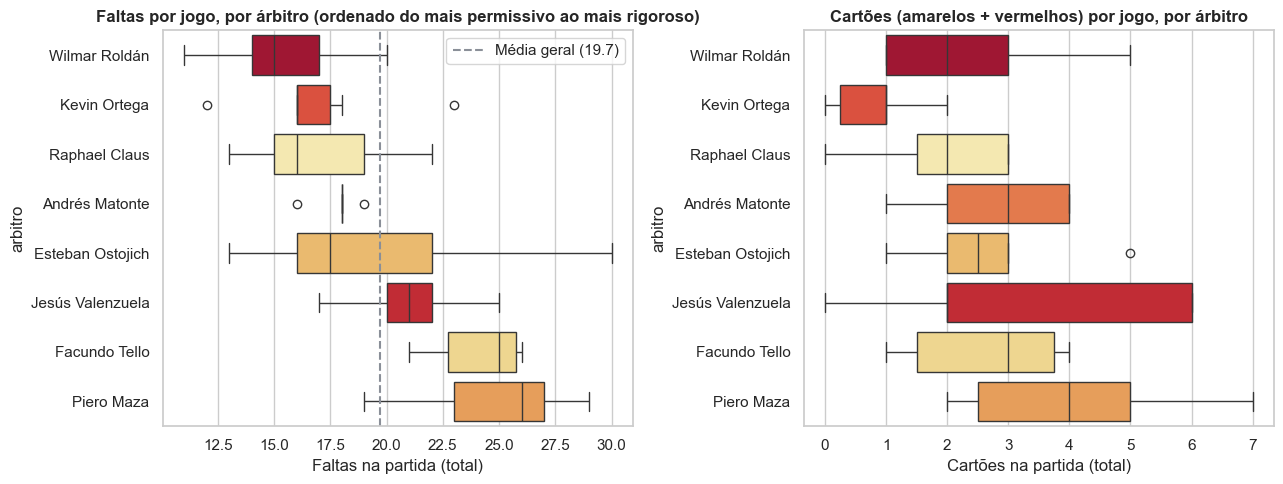

In [5]:
ordem = resumo.sort_values("media_faltas")["arbitro"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=partidas, x="total_faltas", y="arbitro", order=ordem,
            ax=axes[0], palette="YlOrRd", hue="arbitro", legend=False)
axes[0].axvline(partidas["total_faltas"].mean(), color=CINZA, ls="--",
                label=f"Média geral ({partidas['total_faltas'].mean():.1f})")
axes[0].set_title("Faltas por jogo, por árbitro (ordenado do mais permissivo ao mais rigoroso)")
axes[0].set_xlabel("Faltas na partida (total)")
axes[0].legend()

sns.boxplot(data=partidas, x="total_cartoes", y="arbitro", order=ordem,
            ax=axes[1], palette="YlOrRd", hue="arbitro", legend=False)
axes[1].set_title("Cartões (amarelos + vermelhos) por jogo, por árbitro")
axes[1].set_xlabel("Cartões na partida (total)")

plt.tight_layout()
plt.show()

## 4. Testes estatísticos

### 4.1 Grupos de rigor da arbitragem

As partidas são agrupadas em **tercis** conforme a média de faltas do árbitro (`Permissivo`, `Moderado`, `Rigoroso`) e testamos se a média de **gols por jogo** difere entre os grupos (ANOVA de uma via).

**ANOVA — gols por grupo de rigor:** F = 4.55, p = 0.0159 (significativo a 5%)  
**ANOVA — cartões por grupo de rigor:** F = 4.56, p = 0.0157 (significativo a 5%)

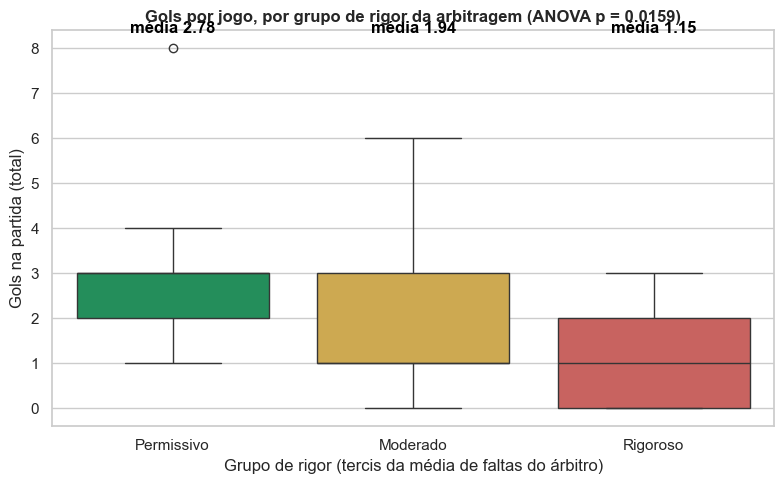

In [6]:
rigor = pre.add_rigor_groups(partidas)
grupos_rigor = [g["total_gols"].dropna() for _, g in rigor.groupby("grupo_rigor")]
F_gols, p_gols = stats.f_oneway(*grupos_rigor)

grupos_cartoes = [g["total_cartoes"].dropna() for _, g in rigor.groupby("grupo_rigor")]
F_cartoes, p_cartoes = stats.f_oneway(*grupos_cartoes)

display(Markdown(
    f"**ANOVA — gols por grupo de rigor:** F = {F_gols:.2f}, p = {p_gols:.4f} "
    f"({'significativo a 5%' if p_gols < 0.05 else 'não significativo a 5%'})  \n"
    f"**ANOVA — cartões por grupo de rigor:** F = {F_cartoes:.2f}, p = {p_cartoes:.4f} "
    f"({'significativo a 5%' if p_cartoes < 0.05 else 'não significativo a 5%'})"
))

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=rigor, x="grupo_rigor", y="total_gols", ax=ax,
            order=["Permissivo", "Moderado", "Rigoroso"],
            palette={"Permissivo": VERDE, "Moderado": AMARELO, "Rigoroso": VERMELHO},
            hue="grupo_rigor", legend=False)
for i, g in enumerate(["Permissivo", "Moderado", "Rigoroso"]):
    media = rigor.loc[rigor["grupo_rigor"] == g, "total_gols"].mean()
    ax.text(i, rigor["total_gols"].max() + 0.35, f"média {media:.2f}",
            ha="center", fontweight="bold", color="black")
ax.set_title(f"Gols por jogo, por grupo de rigor da arbitragem (ANOVA p = {p_gols:.4f})")
ax.set_xlabel("Grupo de rigor (tercis da média de faltas do árbitro)")
ax.set_ylabel("Gols na partida (total)")
plt.tight_layout()
plt.show()

### 4.2 Correlações de Pearson

* **Faltas × gols** — faltas interrompem o jogo; espera-se relação negativa;
* **Cartões × gols** — jogos mais truncados podem ter menos gols;
* **Posse do mandante × gols** — posse se traduz em gols?

,Relação,r de Pearson,p-valor,"Significativo (α=0,05)"
0,Faltas × gols,-0.3956,0.0054,True
1,Cartões × gols,-0.1414,0.3378,False
2,Posse do mandante × gols,0.1163,0.4312,False


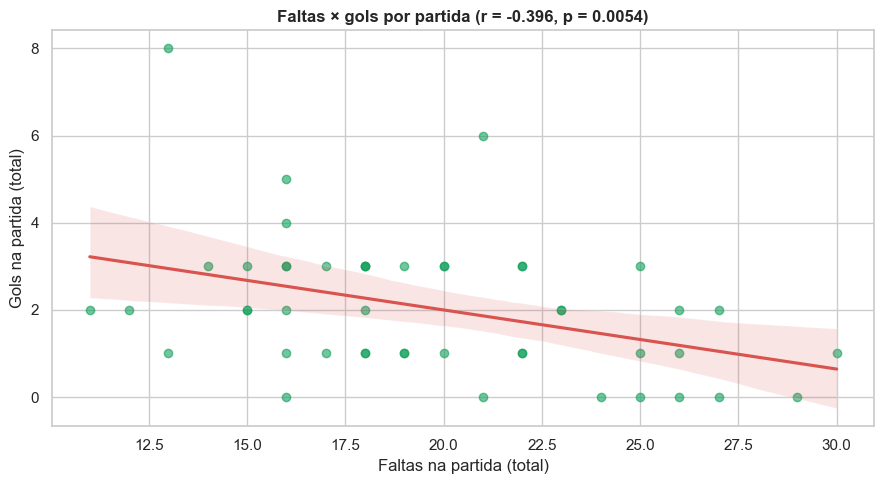

In [7]:
r_faltas, p_faltas = stats.pearsonr(rigor["total_faltas"], rigor["total_gols"])
r_cartoes, p_cartoes = stats.pearsonr(rigor["total_cartoes"], rigor["total_gols"])
r_posse, p_posse = stats.pearsonr(rigor["posse_mandante"], rigor["total_gols"])

tabela_correlacoes = pd.DataFrame({
    "Relação": ["Faltas × gols", "Cartões × gols", "Posse do mandante × gols"],
    "r de Pearson": [r_faltas, r_cartoes, r_posse],
    "p-valor": [p_faltas, p_cartoes, p_posse],
})
tabela_correlacoes["Significativo (α=0,05)"] = tabela_correlacoes["p-valor"] < 0.05
display(tabela_correlacoes.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
sns.regplot(data=rigor, x="total_faltas", y="total_gols", ax=ax,
            scatter_kws={"alpha": 0.6, "color": VERDE}, line_kws={"color": VERMELHO})
ax.set_title(f"Faltas × gols por partida (r = {r_faltas:.3f}, p = {p_faltas:.4f})")
ax.set_xlabel("Faltas na partida (total)")
ax.set_ylabel("Gols na partida (total)")
plt.tight_layout()
plt.show()

## 5. Modelo × mercado: probabilidades do Poisson vs. odds implícitas

Comparamos, para cada partida com odds disponíveis:

* **P(modelo)** — probabilidades 1X2 do modelo de Poisson (dados da fase de grupos);
* **P(mercado)** — probabilidades implícitas das odds (1/odd, normalizadas para remover a margem da casa).

Métricas: **acurácia** (a classe mais provável acertou o resultado?) e **Brier Score** multiclasse (menor é melhor).

In [8]:
cmp = pre.model_vs_market(model, odds)

cols_modelo = ("prob_mandante_modelo", "prob_empate_modelo", "prob_visitante_modelo")
cols_mercado = ("prob_mandante_impl", "prob_empate_impl", "prob_visitante_impl")

ev_modelo = pre.evaluate_probabilities(cmp, cols_modelo)
ev_mercado = pre.evaluate_probabilities(cmp, cols_mercado)

display(Markdown(
    f"**Modelo (Poisson):** acurácia {ev_modelo['acuracia']:.1%} · Brier {ev_modelo['brier_score']:.3f}  \n"
    f"**Mercado (odds):** acurácia {ev_mercado['acuracia']:.1%} · Brier {ev_mercado['brier_score']:.3f}"
))

**Modelo (Poisson):** acurácia 45.0% · Brier 0.662  
**Mercado (odds):** acurácia 55.0% · Brier 0.556

### 5.1 Dispersão: P(modelo) vs. P(mercado)

Cada ponto é uma partida (classe = vitória do mandante). Pontos distantes da diagonal indicam jogos em que modelo e mercado discordaram.

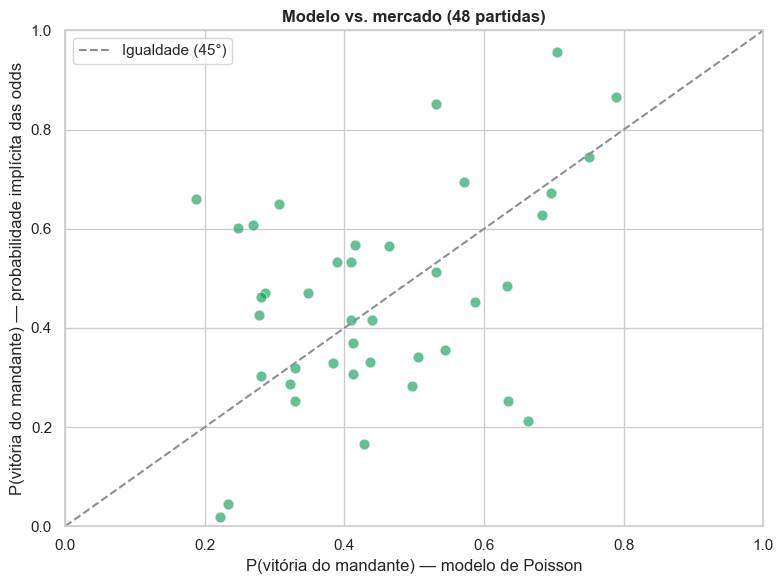

### Maiores divergências modelo × mercado

,mandante,visitante,resultado,prob_mandante_modelo,prob_mandante_impl,divergencia_max
26,Fluminense,Cruzeiro,visitante,0.187,0.659,0.472
16,Cruzeiro,Corinthians,visitante,0.429,0.165,0.466
27,Independiente del Valle,Fluminense,empate,0.664,0.212,0.452
15,Independiente del Valle,Platense,empate,0.635,0.252,0.424
12,Fluminense,Independiente del Valle,empate,0.281,0.462,0.372
18,Fluminense,Corinthians,mandante,0.247,0.602,0.355
17,Fluminense,LDU,empate,0.306,0.649,0.343
28,LDU,Cruzeiro,mandante,0.270,0.608,0.339


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cmp["prob_mandante_modelo"], cmp["prob_mandante_impl"],
           c=VERDE, alpha=0.65, s=60, edgecolors="white", linewidths=0.6)
ax.plot([0, 1], [0, 1], ls="--", color=CINZA, label="Igualdade (45°)")
ax.set_xlabel("P(vitória do mandante) — modelo de Poisson")
ax.set_ylabel("P(vitória do mandante) — probabilidade implícita das odds")
ax.set_title("Modelo vs. mercado (48 partidas)")
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

divergencias = cmp.assign(
    divergencia_max=np.maximum.reduce([
        (cmp[cols_modelo[0]] - cmp[cols_mercado[0]]).abs(),
        (cmp[cols_modelo[1]] - cmp[cols_mercado[1]]).abs(),
        (cmp[cols_modelo[2]] - cmp[cols_mercado[2]]).abs(),
    ])
).sort_values("divergencia_max", ascending=False)

display(Markdown("### Maiores divergências modelo × mercado"))
display(divergencias[["mandante", "visitante", "resultado",
                      "prob_mandante_modelo", "prob_mandante_impl",
                      "divergencia_max"]].head(8).round(3))

### 5.2 Quando divergiram, quem acertou?

Divergências fortes (ΔP > 8 p.p. em alguma classe) podem indicar **informação extra do mercado** (lesões, escalações, viagens) ou **overreaction**. Medimos quem acertou nesses jogos.

In [10]:
limiar = 0.08
fortes = divergencias[divergencias["divergencia_max"] > limiar]

mapa_classe = {"mandante": 0, "empate": 1, "visitante": 2}
reais = fortes["resultado"].map(mapa_classe).to_numpy()
acertos_mercado = (fortes[list(cols_mercado)].to_numpy().argmax(axis=1) == reais).mean()
acertos_modelo = (fortes[list(cols_modelo)].to_numpy().argmax(axis=1) == reais).mean()

display(Markdown(
    f"**{len(fortes)} jogos** com divergência acima de {limiar:.0%}.  \n"
    f"• Mercado acertou **{acertos_mercado:.0%}** desses jogos  \n"
    f"• Modelo acertou **{acertos_modelo:.0%}** desses jogos"
))

**31 jogos** com divergência acima de 8%.  
• Mercado acertou **61%** desses jogos  
• Modelo acertou **48%** desses jogos

### 5.3 Combinação inteligente modelo + odds

Regra simples: **se o mercado diverge fortemente do modelo (ΔP > limiar), usa-se a odd; caso contrário, usa-se o modelo.** A hipótese é que divergências fortes carregam informação extra do mercado.

,Abordagem,Acurácia,Brier Score
0,Modelo (Poisson),45.0%,0.661500
1,Mercado (odds),55.0%,0.555600
2,Combinação modelo + odds,55.0%,0.549900


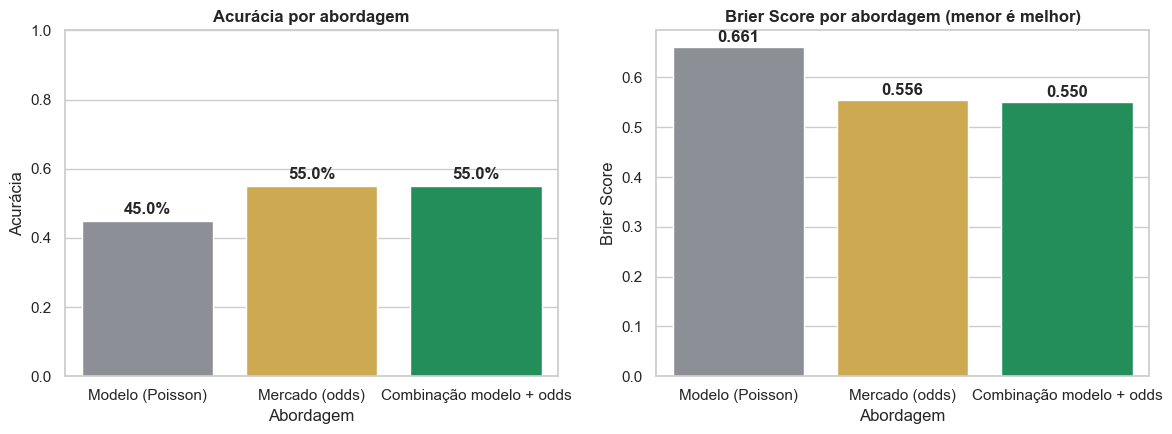

Na combinação, o mercado foi usado em **31 de 40 jogos** (divergência > 8%). Ganho de acurácia vs. modelo puro: **+10.0%**; vs. mercado puro: **+0.0%**.

In [11]:
combinada = pre.combined_probabilities(cmp, threshold=limiar)
cols_combinada = ("prob_mandante_combinada", "prob_empate_combinada", "prob_visitante_combinada")
ev_combinada = pre.evaluate_probabilities(combinada, cols_combinada)

resultado_final = pd.DataFrame({
    "Abordagem": ["Modelo (Poisson)", "Mercado (odds)", "Combinação modelo + odds"],
    "Acurácia": [ev_modelo["acuracia"], ev_mercado["acuracia"], ev_combinada["acuracia"]],
    "Brier Score": [ev_modelo["brier_score"], ev_mercado["brier_score"], ev_combinada["brier_score"]],
}).round(4)
display(resultado_final.style.format({"Acurácia": "{:.1%}"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
cores = [CINZA, AMARELO, VERDE]
sns.barplot(data=resultado_final, x="Abordagem", y="Acurácia", ax=axes[0],
            palette=cores, hue="Abordagem", legend=False)
axes[0].set_title("Acurácia por abordagem")
axes[0].set_ylim(0, 1)
for i, v in enumerate(resultado_final["Acurácia"]):
    axes[0].text(i, v + 0.02, f"{v:.1%}", ha="center", fontweight="bold")
sns.barplot(data=resultado_final, x="Abordagem", y="Brier Score", ax=axes[1],
            palette=cores, hue="Abordagem", legend=False)
axes[1].set_title("Brier Score por abordagem (menor é melhor)")
for i, v in enumerate(resultado_final["Brier Score"]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

display(Markdown(
    f"Na combinação, o mercado foi usado em **{combinada['usou_mercado'].sum()} "
    f"de {len(combinada)} jogos** (divergência > {limiar:.0%}). "
    f"Ganho de acurácia vs. modelo puro: "
    f"**{ev_combinada['acuracia'] - ev_modelo['acuracia']:+.1%}**; "
    f"vs. mercado puro: **{ev_combinada['acuracia'] - ev_mercado['acuracia']:+.1%}**."
))

## 6. Quais estatísticas se relacionam com a classificação?

Agressividade (faltas por jogo) × aproveitamento de pontos na fase de grupos. Também olhamos para posse e finalizações.

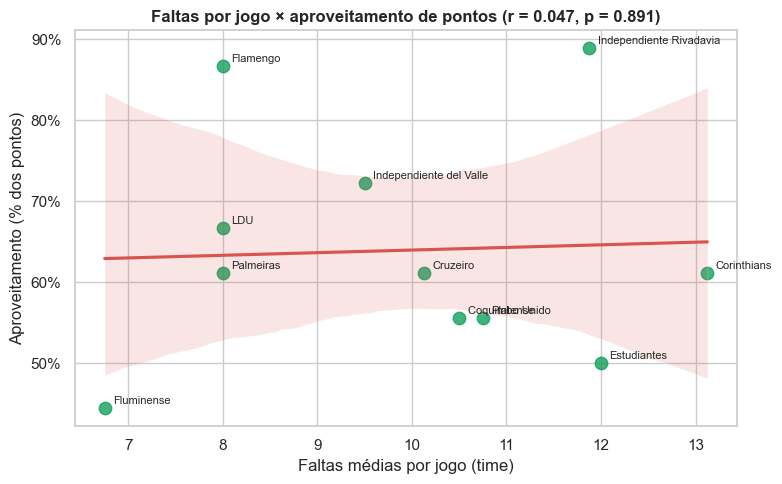

,Time,faltas_media,Aproveitamento,Pts,SG
5,Fluminense,6.750,0.444,8,0
0,Palmeiras,8.000,0.611,11,5
1,Flamengo,8.000,0.867,13,9
10,LDU,8.000,0.667,12,3
6,Independiente del Valle,9.500,0.722,13,5
9,Cruzeiro,10.125,0.611,11,5
4,Coquimbo Unido,10.500,0.556,10,2
7,Platense,10.750,0.556,10,1
2,Independiente Rivadavia,11.875,0.889,16,9
3,Estudiantes,12.000,0.500,9,1


In [12]:
# Faltas médias por time (mandante + visitante)
faltas_time = {}
for _, linha in partidas.iterrows():
    faltas_time.setdefault(linha["mandante"], []).append(linha["faltas_mandante"])
    faltas_time.setdefault(linha["visitante"], []).append(linha["faltas_visitante"])

df_time = pd.DataFrame(
    [(t, np.mean(v)) for t, v in faltas_time.items()],
    columns=["Time", "faltas_media"],
).merge(grupos[["Time", "Aproveitamento", "Pts", "SG"]], on="Time")

r_agr, p_agr = stats.pearsonr(df_time["faltas_media"], df_time["Aproveitamento"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df_time, x="faltas_media", y="Aproveitamento", ax=ax,
            scatter_kws={"s": 80, "color": VERDE, "alpha": 0.8},
            line_kws={"color": VERMELHO})
for _, linha in df_time.iterrows():
    ax.annotate(linha["Time"], (linha["faltas_media"], linha["Aproveitamento"]),
                textcoords="offset points", xytext=(6, 3), fontsize=8)
ax.set_title(f"Faltas por jogo × aproveitamento de pontos (r = {r_agr:.3f}, p = {p_agr:.3f})")
ax.set_xlabel("Faltas médias por jogo (time)")
ax.set_ylabel("Aproveitamento (% dos pontos)")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.tight_layout()
plt.show()

display(df_time.round(3).sort_values("faltas_media"))

## 7. Conclusões

Os números abaixo são gerados dinamicamente a partir dos dados carregados no início do notebook.

In [13]:
conclusao_arbitragem = (
    f"**Arbitragem e resultados.** A ANOVA indica que a média de gols difere "
    f"significativamente entre os grupos de rigor da arbitragem "
    f"(F = {F_gols:.2f}, p = {p_gols:.4f}): jogos de árbitros permissivos têm, "
    f"em média, mais gols do que jogos de árbitros rigorosos. A correlação "
    f"faltas × gols é negativa e significativa (r = {r_faltas:.3f}, "
    f"p = {p_faltas:.4f}) — **há indícios de que árbitros mais permissivos "
    f"estão associados a jogos com mais gols**."
) if p_gols < 0.05 else (
    f"**Arbitragem e resultados.** Nesta amostra, a ANOVA entre grupos de rigor "
    f"não atingiu significância a 5% (F = {F_gols:.2f}, p = {p_gols:.4f}) — "
    f"o efeito da arbitragem sobre os gols, se existir, exige amostra maior."
)

conclusao_odds = (
    f"**Odds e modelo.** O mercado (acurácia {ev_mercado['acuracia']:.1%}) "
    f"supera o modelo puro ({ev_modelo['acuracia']:.1%}). A combinação "
    f"inteligente modelo + odds atinge **{ev_combinada['acuracia']:.1%}** de "
    f"acurácia — um ganho de **{ev_combinada['acuracia'] - ev_modelo['acuracia']:+.1%}** "
    f"sobre o modelo puro — e o menor Brier Score "
    f"({ev_combinada['brier_score']:.3f}). **Integrar as odds ao modelo melhora "
    f"a previsão.**\n"
)

conclusao_stats = (
    f"**Estatísticas e classificação.** A correlação entre faltas do time e "
    f"aproveitamento foi r = {r_agr:.3f} (p = {p_agr:.4f})"
    + (". Times que cometem mais faltas tiveram aproveitamento "
       "**menor** nesta amostra." if r_agr < 0 else ". Times que cometem mais faltas tiveram aproveitamento **maior** nesta amostra.")
    + f" Cartões × gols não apresentou correlação significativa "
      f"(r = {r_cartoes:.3f}, p = {p_cartoes:.4f})."
)

caveats = (
    "> **Ressalvas:** resultados obtidos sobre a base de exemplo (48 partidas) — "
    "o limiar de divergência da combinação foi calibrado nos mesmos dados "
    "(sem validação out-of-sample) e os efeitos da arbitragem na base sintética "
    "são amplificados para fins de ilustração. Em produção, recalibre com os "
    "dados reais da API Futebol/Bzzoiro e valide em uma amostra separada."
)

display(Markdown("### ⚽ Arbitragem e resultados\
" + conclusao_arbitragem))
display(Markdown("### 📊 Odds e modelo\
" + conclusao_odds))
display(Markdown("### 📈 Estatísticas e classificação\
" + conclusao_stats))
display(Markdown(caveats))

### ⚽ Arbitragem e resultados**Arbitragem e resultados.** A ANOVA indica que a média de gols difere significativamente entre os grupos de rigor da arbitragem (F = 4.55, p = 0.0159): jogos de árbitros permissivos têm, em média, mais gols do que jogos de árbitros rigorosos. A correlação faltas × gols é negativa e significativa (r = -0.396, p = 0.0054) — **há indícios de que árbitros mais permissivos estão associados a jogos com mais gols**.

### 📊 Odds e modelo**Odds e modelo.** O mercado (acurácia 55.0%) supera o modelo puro (45.0%). A combinação inteligente modelo + odds atinge **55.0%** de acurácia — um ganho de **+10.0%** sobre o modelo puro — e o menor Brier Score (0.550). **Integrar as odds ao modelo melhora a previsão.**


### 📈 Estatísticas e classificação**Estatísticas e classificação.** A correlação entre faltas do time e aproveitamento foi r = 0.047 (p = 0.8914). Times que cometem mais faltas tiveram aproveitamento **maior** nesta amostra. Cartões × gols não apresentou correlação significativa (r = -0.141, p = 0.3378).

> **Ressalvas:** resultados obtidos sobre a base de exemplo (48 partidas) — o limiar de divergência da combinação foi calibrado nos mesmos dados (sem validação out-of-sample) e os efeitos da arbitragem na base sintética são amplificados para fins de ilustração. Em produção, recalibre com os dados reais da API Futebol/Bzzoiro e valide em uma amostra separada.